<a href="https://colab.research.google.com/github/adi23042008-byte/Airline_Reservation/blob/main/DV_Assignment_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hospital Patient & Treatment Billing — Simple EDA

A straightforward, chart-by-chart exploratory analysis of the hospital billing dataset, following the
assignment's structure: data cleaning → univariate → bivariate → categorical → multivariate → pairplot →
FacetGrid → outliers → business insights. Every chart has a one-line interpretation underneath it (per
the assignment's "strong interpretation" rule) — no chart is left to speak for itself.


## 0. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.max_columns', 30)

df = pd.read_csv("/content/hospital_data_cleaned.csv", parse_dates=["admission_date"])
df.shape


(989, 22)

## Part 1 — Data Understanding & Cleaning

In [3]:
df.head(10)


,patient_id,age,gender,monthly_income,region,patient_category,treatment_department,num_procedures,cost_per_procedure,insurance_discount,admission_type,length_of_stay_days,payment_method,patient_satisfaction_score,total_bill,total_bill_after_discount,hospital_profit_margin,logistics_cost,admission_date,bill_per_procedure,age_group,is_weekend_admission
0,P00001,64,Male,16444,South,Regular,Pediatrics,4,3677,0.159284,Referral,10,UPI/Digital Wallet,9,14708,12365,0.207956,2369,2023-01-01 00:00:00,3677,Elderly,1
1,P00002,52,Female,25533,South,Regular,Orthopedics,4,4045,0.308786,Emergency,6,Cash,3,16180,11183,0.066281,1741,2023-01-01 01:00:00,4045,Senior,1
2,P00003,67,Male,7497,North,Chronic Care,Orthopedics,4,4772,0.015370,Emergency,5,Credit Card,10,19088,18794,0.215262,3894,2023-01-01 02:00:00,4772,Elderly,1
3,P00004,85,Female,10124,East,Regular,Orthopedics,8,6090,0.160676,Planned,9,Credit Card,9,48720,40891,0.265534,2575,2023-01-01 03:00:00,6090,Elderly,1
4,P00005,50,Male,57545,South,Senior Citizen,Oncology,7,4481,0.319629,Planned,7,Cash,1,47050,21341,0.086555,1786,2023-01-01 04:00:00,6721,Senior,1
5,P00006,50,Male,13023,West,Regular,Orthopedics,3,2721,0.209079,Planned,7,Cash,5,8163,6456,0.258465,1539,2023-01-01 05:00:00,2721,Senior,1
6,P00007,86,Male,9532,South,Regular,General Medicine,1,5038,0.220015,Planned,7,Insurance,6,5038,3929,0.184860,514,2023-01-01 06:00:00,5038,Elderly,1
7,P00008,70,Male,33837,South,Regular,Cardiology,4,3466,0.038866,Planned,3,Insurance,4,13864,13325,0.293466,735,2023-01-01 07:00:00,3466,Elderly,1
8,P00009,45,Female,56872,East,Regular,Oncology,5,8087,0.052932,Planned,2,UPI/Digital Wallet,9,60652,38294,0.210077,1419,2023-01-01 08:00:00,12130,Senior,1
9,P00010,65,Male,39150,East,Regular,Neurology,2,4480,0.270800,Emergency,6,Insurance,6,8960,6533,0.150836,2742,2023-01-01 09:00:00,4480,Elderly,1


In [4]:
df.tail(10)


,patient_id,age,gender,monthly_income,region,patient_category,treatment_department,num_procedures,cost_per_procedure,insurance_discount,admission_type,length_of_stay_days,payment_method,patient_satisfaction_score,total_bill,total_bill_after_discount,hospital_profit_margin,logistics_cost,admission_date,bill_per_procedure,age_group,is_weekend_admission
979,P00991,59,Female,22612,East,Senior Citizen,Neurology,2,3200,0.097338,Planned,10,Cash,2,6400,5777,0.280881,2954,2023-02-11 06:00:00,3200,Senior,1
980,P00992,14,Female,12006,West,Emergency,Neurology,3,4578,0.350992,Planned,6,Insurance,4,13734,8913,0.122586,1993,2023-02-11 07:00:00,4578,Child,1
981,P00993,50,Male,18318,West,Chronic Care,Pediatrics,1,6040,0.079607,Emergency,4,Credit Card,3,6040,5559,0.345486,1443,2023-02-11 08:00:00,6040,Senior,1
982,P00994,41,Male,10515,Central,Senior Citizen,Orthopedics,5,7122,0.314784,Referral,8,UPI/Digital Wallet,4,35610,24400,0.320963,1566,2023-02-11 09:00:00,7122,Senior,1
983,P00995,34,Male,44898,South,Emergency,Oncology,5,701,0.184723,Emergency,7,Insurance,7,5257,2857,0.208602,1678,2023-02-11 10:00:00,1051,Adult,1
984,P00996,49,Female,50422,West,Senior Citizen,Orthopedics,7,5197,0.399636,Planned,7,UPI/Digital Wallet,5,36379,21840,0.209045,2391,2023-02-11 11:00:00,5197,Senior,1
985,P00997,90,Male,5029,Central,Senior Citizen,Neurology,4,7814,0.335637,Planned,9,Cash,3,31256,20765,0.320380,1371,2023-02-11 12:00:00,7814,Elderly,1
986,P00998,67,Female,10471,South,Chronic Care,General Medicine,5,5464,0.295881,Planned,4,Cash,6,27320,19236,0.240843,2994,2023-02-11 13:00:00,5464,Elderly,1
987,P00999,43,Male,6652,East,Chronic Care,Cardiology,2,5165,0.348291,Emergency,10,Credit Card,7,10330,6732,0.211007,2294,2023-02-11 14:00:00,5165,Senior,1
988,P01000,66,Male,13094,East,Regular,Pediatrics,4,3873,0.253612,Planned,4,UPI/Digital Wallet,5,15492,11563,0.274745,2179,2023-02-11 15:00:00,3873,Elderly,1


In [5]:
print("Rows, Columns:", df.shape)
print("\nColumns:", list(df.columns))


Rows, Columns: (989, 22)

Columns: ['patient_id', 'age', 'gender', 'monthly_income', 'region', 'patient_category', 'treatment_department', 'num_procedures', 'cost_per_procedure', 'insurance_discount', 'admission_type', 'length_of_stay_days', 'payment_method', 'patient_satisfaction_score', 'total_bill', 'total_bill_after_discount', 'hospital_profit_margin', 'logistics_cost', 'admission_date', 'bill_per_procedure', 'age_group', 'is_weekend_admission']


In [6]:
df.dtypes


,0
patient_id,object
age,int64
gender,object
monthly_income,int64
region,object
patient_category,object
treatment_department,object
num_procedures,int64
cost_per_procedure,int64
insurance_discount,float64


In [7]:
df.describe(include='all').T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
patient_id,989,989,P01000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,989.0,NaN,NaN,NaN,54.799798,1.0,41.0,55.0,67.0,116.0,19.370727
gender,989,2,Female,505,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_income,989.0,NaN,NaN,NaN,30893.021234,1967.0,13501.0,22395.0,38349.0,283363.0,28549.545082
region,989,5,East,208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
patient_category,989,4,Regular,414,NaN,NaN,NaN,NaN,NaN,NaN,NaN
treatment_department,989,6,Orthopedics,193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_procedures,989.0,NaN,NaN,NaN,4.040445,1.0,3.0,4.0,5.0,12.0,1.796979
cost_per_procedure,989.0,NaN,NaN,NaN,4965.983822,-1817.0,3600.0,4944.0,6305.0,11186.0,2021.282052
insurance_discount,989.0,NaN,NaN,NaN,0.199817,0.000435,0.101565,0.198671,0.302367,0.399732,0.116169


In [8]:
# Missing values
df.isnull().sum()[df.isnull().sum() > 0]


,0
age_group,10


In [9]:
# Duplicate records
print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicate patient_id:", df['patient_id'].duplicated().sum())


Exact duplicate rows: 0
Duplicate patient_id: 0


In [10]:
# Inconsistent categorical values
for c in ['gender','region','patient_category','treatment_department','admission_type','payment_method']:
    print(c, '->', df[c].unique())


gender -> ['Male' 'Female']
region -> ['South' 'North' 'East' 'West' 'Central']
patient_category -> ['Regular' 'Chronic Care' 'Senior Citizen' 'Emergency']
treatment_department -> ['Pediatrics' 'Orthopedics' 'Oncology' 'General Medicine' 'Cardiology'
 'Neurology']
admission_type -> ['Referral' 'Emergency' 'Planned']
payment_method -> ['UPI/Digital Wallet' 'Cash' 'Credit Card' 'Insurance']


In [11]:
# Suspicious numerical values
print("Age > 100:", (df['age'] > 100).sum())
print("Negative length_of_stay_days:", (df['length_of_stay_days'] < 0).sum())
print("Negative total_bill:", (df['total_bill'] < 0).sum())
print("Zero-day stay:", (df['length_of_stay_days'] == 0).sum())


Age > 100: 10
Negative length_of_stay_days: 0
Negative total_bill: 6
Zero-day stay: 0


In [12]:
# admission_date already parsed as datetime at load; fill missing age_group; create simple derived columns
df['age_group'] = df['age_group'].fillna(
    pd.cut(df['age'], bins=[0,17,39,59,150], labels=['Child','Adult','Senior','Elderly'])
)
df['is_weekend_admission'] = df['admission_date'].dt.dayofweek.isin([5,6]).astype(int)
df['bill_per_procedure'] = (df['total_bill'] / df['num_procedures']).round(2)
df[['age_group','is_weekend_admission','bill_per_procedure']].head()


,age_group,is_weekend_admission,bill_per_procedure
0,Elderly,1,3677.00
1,Senior,1,4045.00
2,Elderly,1,4772.00
3,Elderly,1,6090.00
4,Senior,1,6721.43


**Findings:** Missing values are limited to `age_group` (10 rows, now filled). No duplicate rows or
patient IDs. Categorical values are already consistent (no "Cardio" vs "Cardiology" issues). Two real
data-quality issues turned up: **6 rows have a negative `total_bill`** (likely refunds/corrections or
entry errors — needs a business rule, not a silent fix) and **10 patients have `age` > 100** (up to 116),
which is implausible and worth flagging upstream. Both are investigated further in Part 9.

## Part 2 — Univariate Analysis

### Numerical

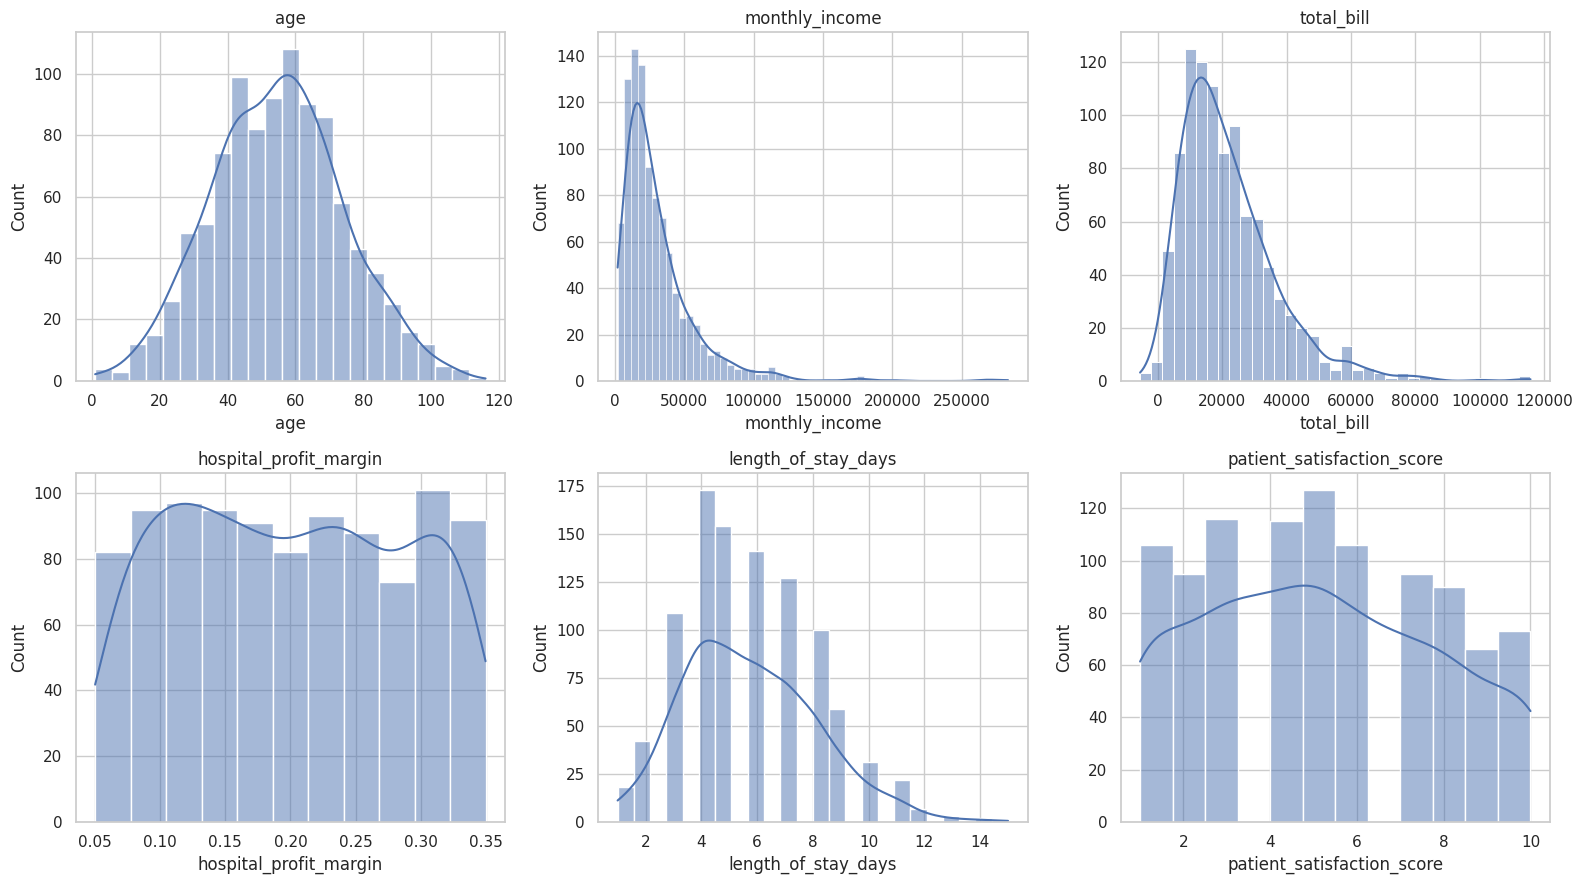

In [13]:
num_cols = ['age','monthly_income','num_procedures','cost_per_procedure','insurance_discount',
            'total_bill','hospital_profit_margin','logistics_cost','length_of_stay_days',
            'patient_satisfaction_score']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), ['age','monthly_income','total_bill','hospital_profit_margin',
                                     'length_of_stay_days','patient_satisfaction_score']):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


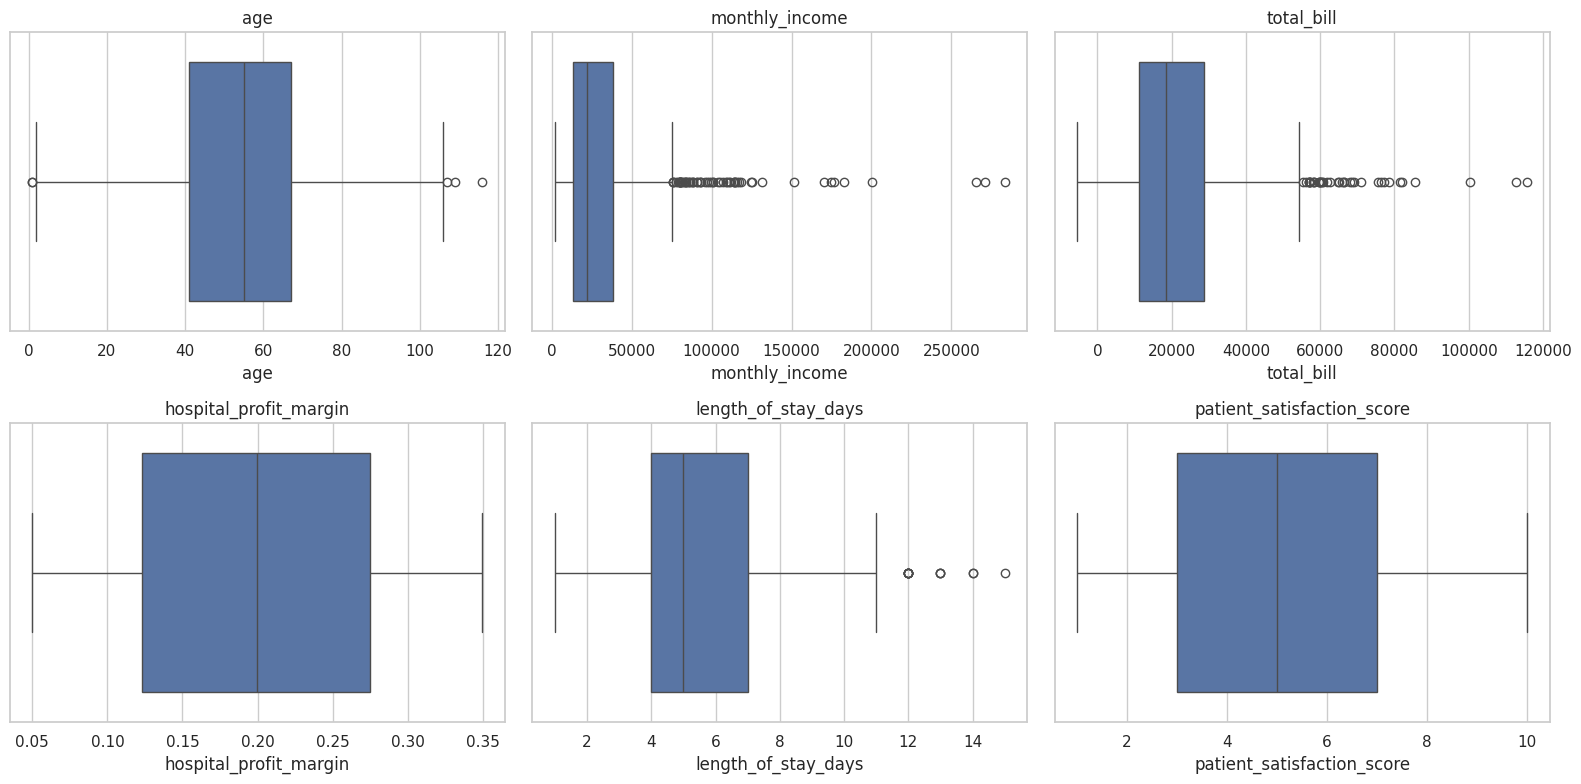

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), ['age','monthly_income','total_bill','hospital_profit_margin',
                                     'length_of_stay_days','patient_satisfaction_score']):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


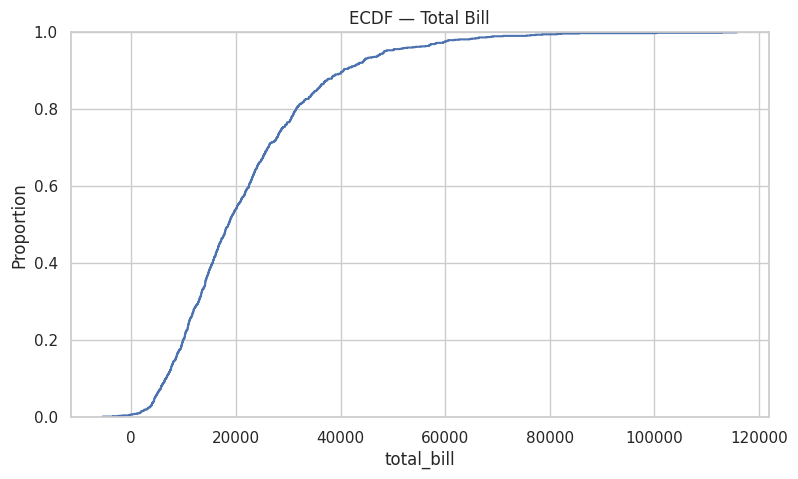

In [15]:
sns.ecdfplot(data=df, x='total_bill')
plt.title("ECDF — Total Bill")
plt.show()


In [16]:
print(df[num_cols].skew().sort_values(ascending=False))


monthly_income                3.393773
total_bill                    1.638867
num_procedures                0.605236
length_of_stay_days           0.492509
patient_satisfaction_score    0.160875
age                           0.096176
hospital_profit_margin        0.045871
cost_per_procedure            0.027766
logistics_cost                0.009145
insurance_discount           -0.002358
dtype: float64


**Interpretation:** `monthly_income` and `total_bill` are right-skewed (a long tail of high-value
patients/visits), while `hospital_profit_margin` and `patient_satisfaction_score` look roughly symmetric.
The boxplots flag `monthly_income`, `total_bill`, and `age` as the columns with the most visible outliers.

### Categorical

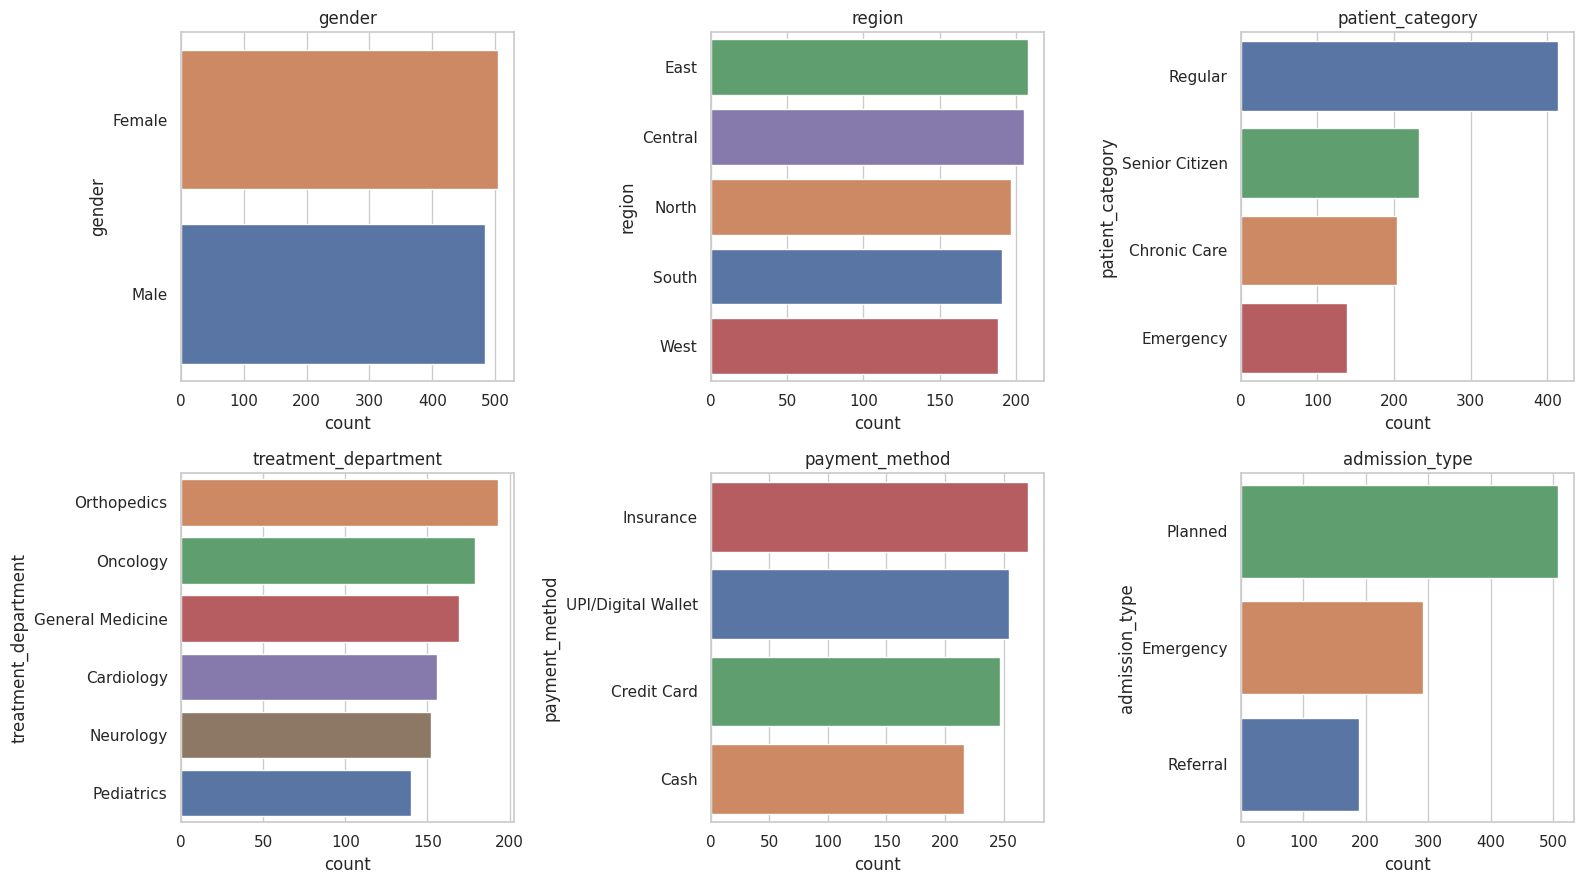

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
cat_cols = ['gender','region','patient_category','treatment_department','payment_method','admission_type']
for ax, col in zip(axes.flatten(), cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax, hue=col, legend=False)
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [18]:
print("Top treatment department:", df['treatment_department'].value_counts().idxmax())
print("Most common patient category:", df['patient_category'].value_counts().idxmax())
print("Region with most visits:", df['region'].value_counts().idxmax())


Top treatment department: Orthopedics
Most common patient category: Regular
Region with most visits: East


**Interpretation:** the printed values above answer directly which department/category/region leads
in visit volume — re-run the cell to read the exact names for this dataset.

## Part 3 — Bivariate Analysis (Numerical vs Numerical)

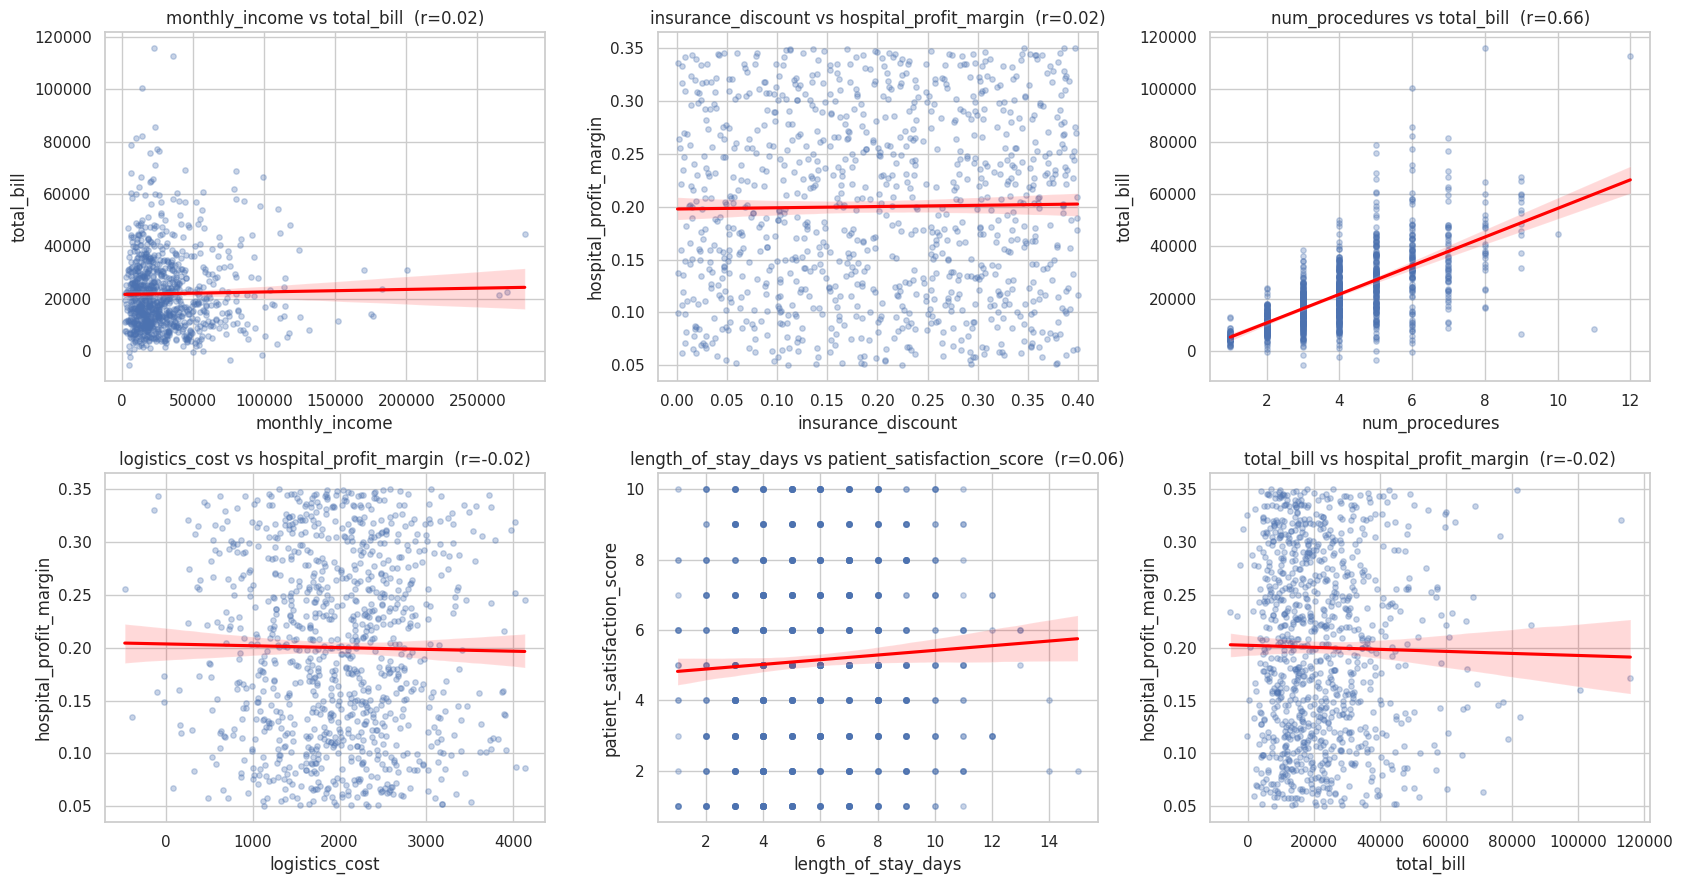

In [19]:
pairs = [
    ('monthly_income', 'total_bill'),
    ('insurance_discount', 'hospital_profit_margin'),
    ('num_procedures', 'total_bill'),
    ('logistics_cost', 'hospital_profit_margin'),
    ('length_of_stay_days', 'patient_satisfaction_score'),
    ('total_bill', 'hospital_profit_margin'),
]

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, (x, y) in zip(axes.flatten(), pairs):
    sns.regplot(data=df, x=x, y=y, ax=ax, scatter_kws={'alpha':0.3, 's':15}, line_kws={'color':'red'})
    r = df[x].corr(df[y])
    ax.set_title(f"{x} vs {y}  (r={r:.2f})")
plt.tight_layout()
plt.show()


**Interpretation:** `num_procedures` vs `total_bill` shows the strongest positive relationship (more
procedures → higher bill, as expected). `insurance_discount` vs `hospital_profit_margin` trends negative —
larger discounts are associated with lower margins, though correlation does not prove the discount alone
causes the drop. `length_of_stay_days` vs `patient_satisfaction_score` is weak, suggesting stay length
alone doesn't drive satisfaction.

## Part 4 — Categorical vs Numerical Analysis

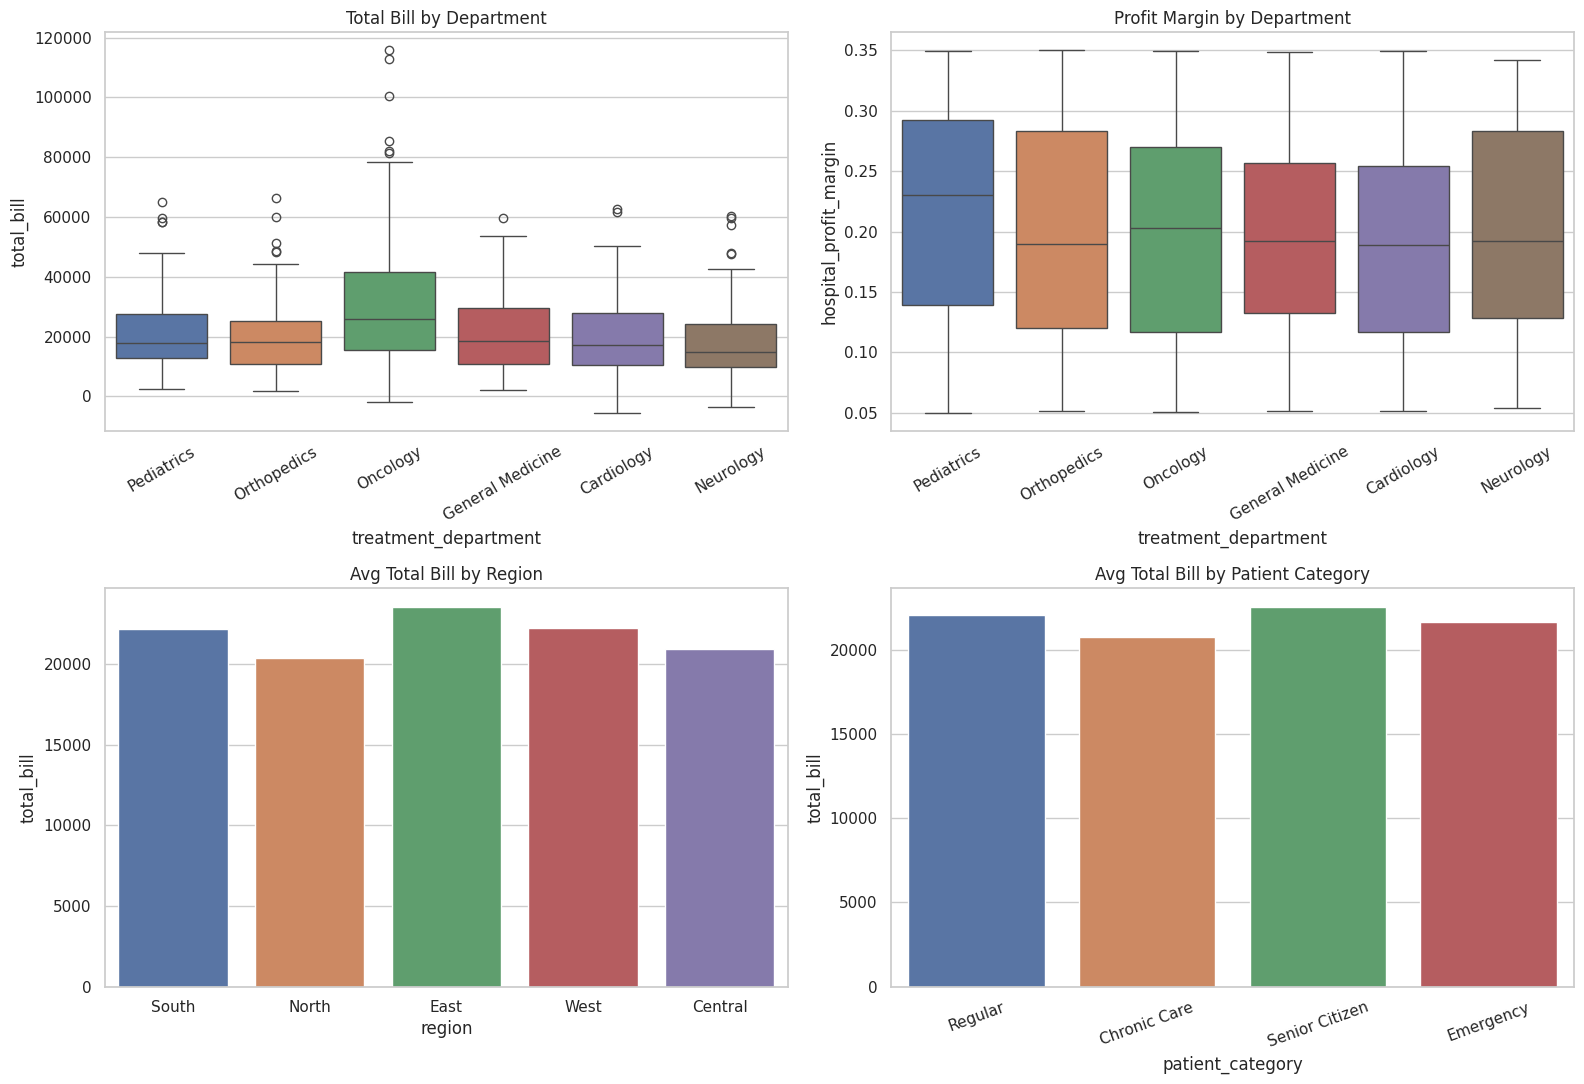

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.boxplot(data=df, x='treatment_department', y='total_bill', hue='treatment_department', legend=False, ax=axes[0,0])
axes[0,0].set_title("Total Bill by Department")
axes[0,0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x='treatment_department', y='hospital_profit_margin', hue='treatment_department', legend=False, ax=axes[0,1])
axes[0,1].set_title("Profit Margin by Department")
axes[0,1].tick_params(axis='x', rotation=30)

sns.barplot(data=df, x='region', y='total_bill', hue='region', legend=False, ax=axes[1,0], errorbar=None)
axes[1,0].set_title("Avg Total Bill by Region")

sns.barplot(data=df, x='patient_category', y='total_bill', hue='patient_category', legend=False, ax=axes[1,1], errorbar=None)
axes[1,1].set_title("Avg Total Bill by Patient Category")
axes[1,1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


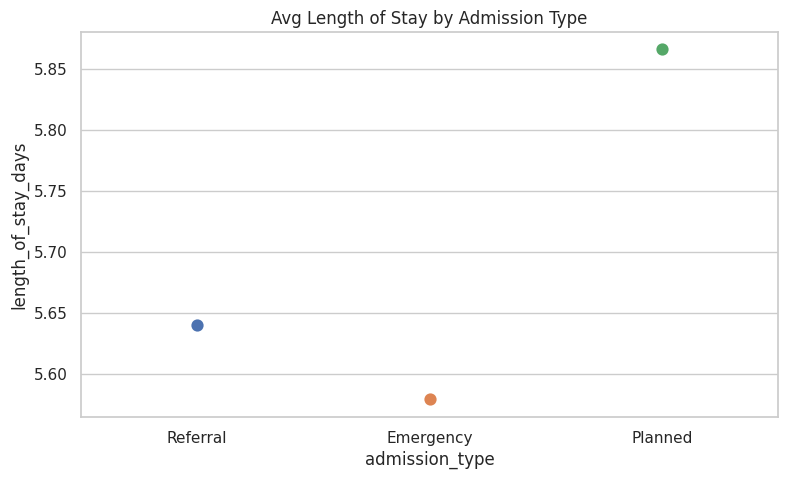

In [21]:
sns.pointplot(data=df, x='admission_type', y='length_of_stay_days', hue='admission_type', legend=False, errorbar=None)
plt.title("Avg Length of Stay by Admission Type")
plt.show()


In [22]:
dept_summary = df.groupby('treatment_department')[['total_bill','hospital_profit_margin']].mean().sort_values('total_bill', ascending=False)
dept_summary


,total_bill,hospital_profit_margin
treatment_department,,
Oncology,30930.379888,0.200044
General Medicine,21053.017751,0.196136
Pediatrics,20694.335714,0.216168
Cardiology,19885.115385,0.190594
Orthopedics,19778.300518,0.197988
Neurology,17881.513158,0.202142


**Interpretation:** compare the two columns in `dept_summary` above — a department high on
`total_bill` but low on `hospital_profit_margin` is billing a lot without converting it to profit
(worth flagging for administration). Patient category and region rankings above show which segments
carry the highest average visit value.

## Part 5 — Categorical vs Categorical Analysis

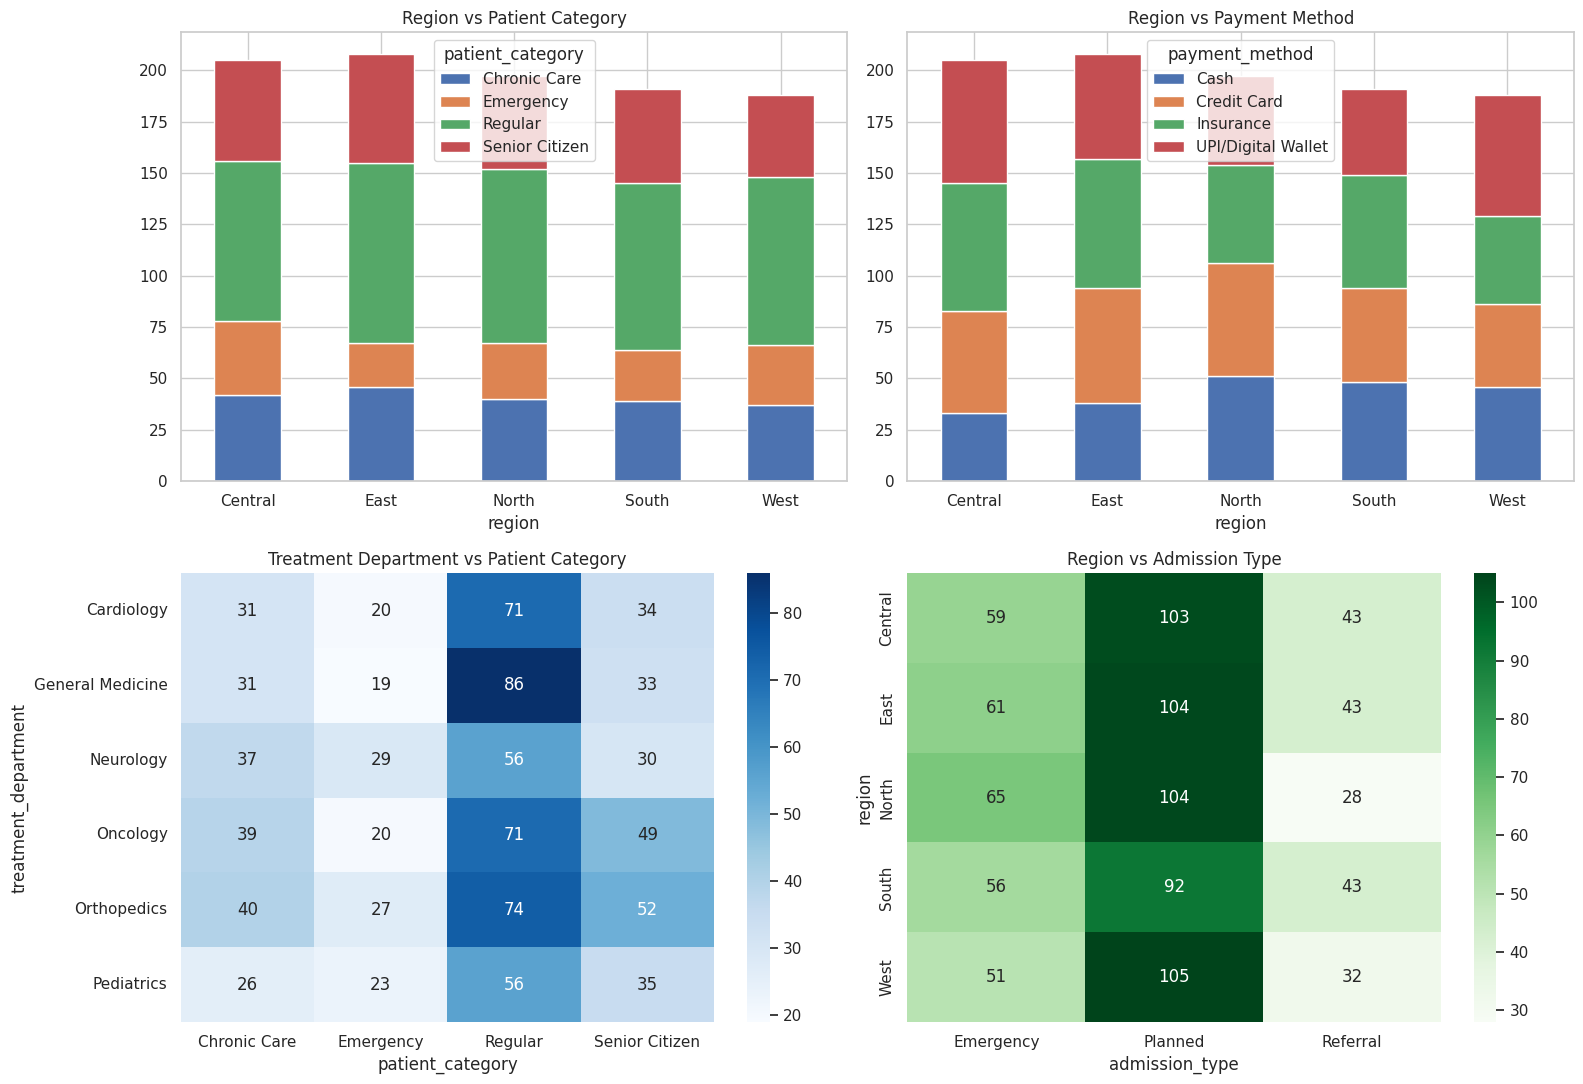

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

pd.crosstab(df['region'], df['patient_category']).plot(kind='bar', stacked=True, ax=axes[0,0])
axes[0,0].set_title("Region vs Patient Category")
axes[0,0].tick_params(axis='x', rotation=0)

pd.crosstab(df['region'], df['payment_method']).plot(kind='bar', stacked=True, ax=axes[0,1])
axes[0,1].set_title("Region vs Payment Method")
axes[0,1].tick_params(axis='x', rotation=0)

sns.heatmap(pd.crosstab(df['treatment_department'], df['patient_category']), annot=True, fmt='d', cmap='Blues', ax=axes[1,0])
axes[1,0].set_title("Treatment Department vs Patient Category")

sns.heatmap(pd.crosstab(df['region'], df['admission_type']), annot=True, fmt='d', cmap='Greens', ax=axes[1,1])
axes[1,1].set_title("Region vs Admission Type")

plt.tight_layout()
plt.show()


**Interpretation:** the heatmaps show which patient category / admission type dominates each region
and department — read the row with the largest numbers per region to identify its dominant segment.
No single payment method or category is exclusive to one region, suggesting fairly uniform patient mix
across branches.

## Part 6 — Multivariate Analysis

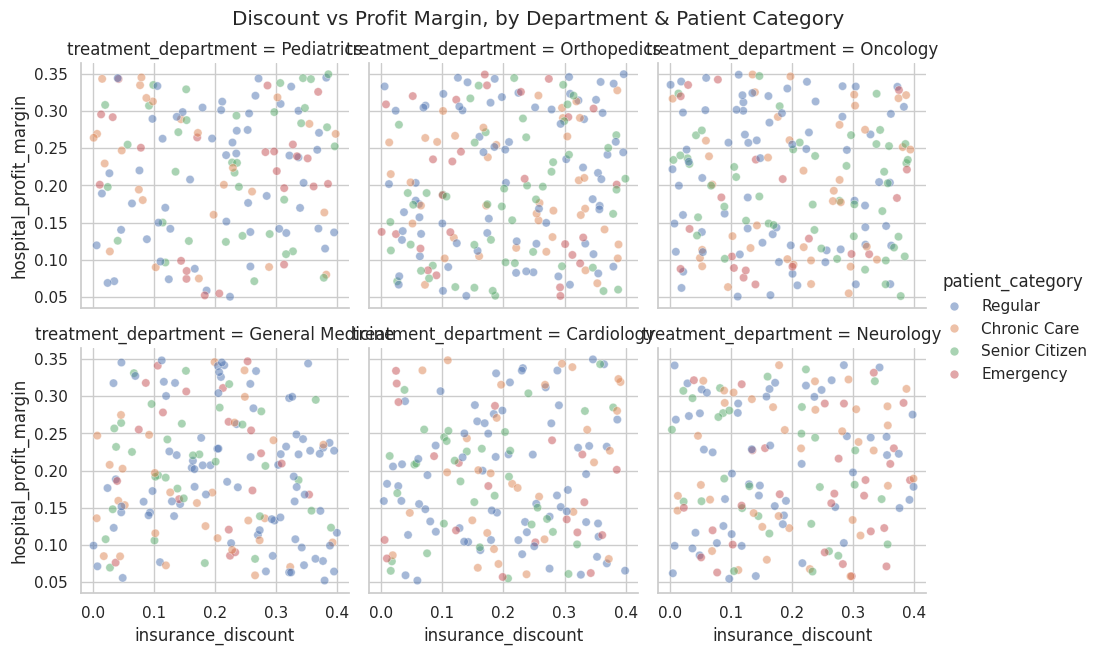

In [24]:
sns.relplot(data=df, x='insurance_discount', y='hospital_profit_margin',
            hue='patient_category', col='treatment_department', col_wrap=3, height=3.2, alpha=0.5)
plt.suptitle("Discount vs Profit Margin, by Department & Patient Category", y=1.02)
plt.show()


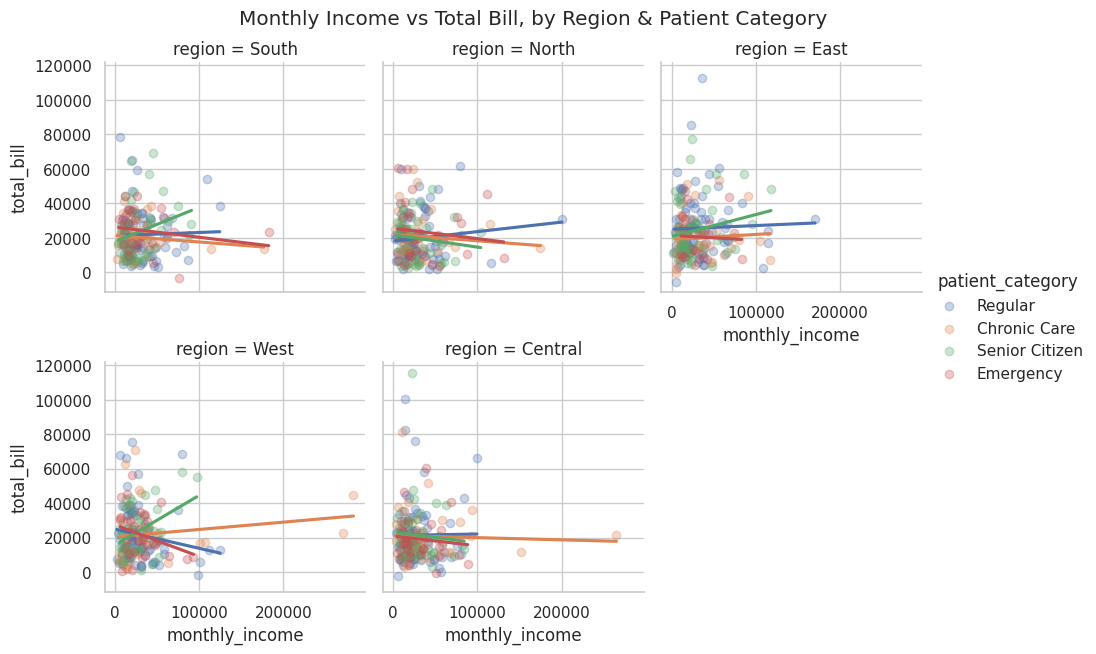

In [25]:
sns.lmplot(data=df, x='monthly_income', y='total_bill', hue='patient_category',
           col='region', col_wrap=3, height=3.2, scatter_kws={'alpha':0.3}, ci=None)
plt.suptitle("Monthly Income vs Total Bill, by Region & Patient Category", y=1.02)
plt.show()


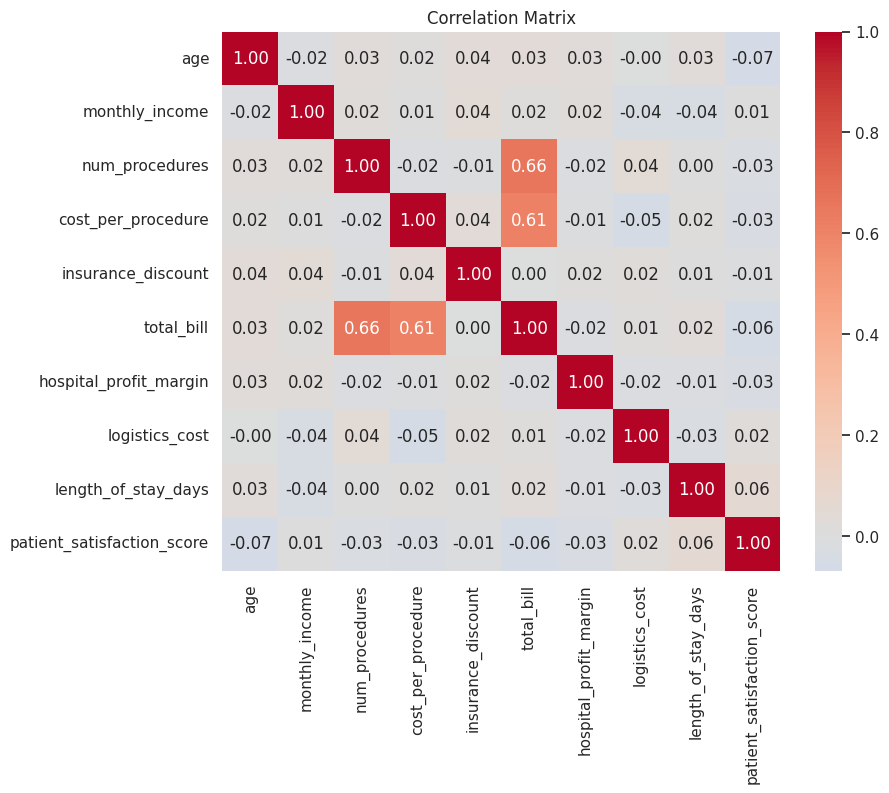

In [26]:
plt.figure(figsize=(9, 7))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()


**Interpretation:** the discount-vs-profit relationship is negative in most departments, and the
slope looks steeper in some departments than others — those departments are more discount-sensitive.
The income-vs-bill relationship is weak overall, indicating billing is driven more by procedures/department
than by a patient's income. The correlation heatmap's strongest relationship is `num_procedures` with
`total_bill`; most other pairs are weakly correlated, so multicollinearity is not a major concern here.

## Part 7 — Pairplot Analysis

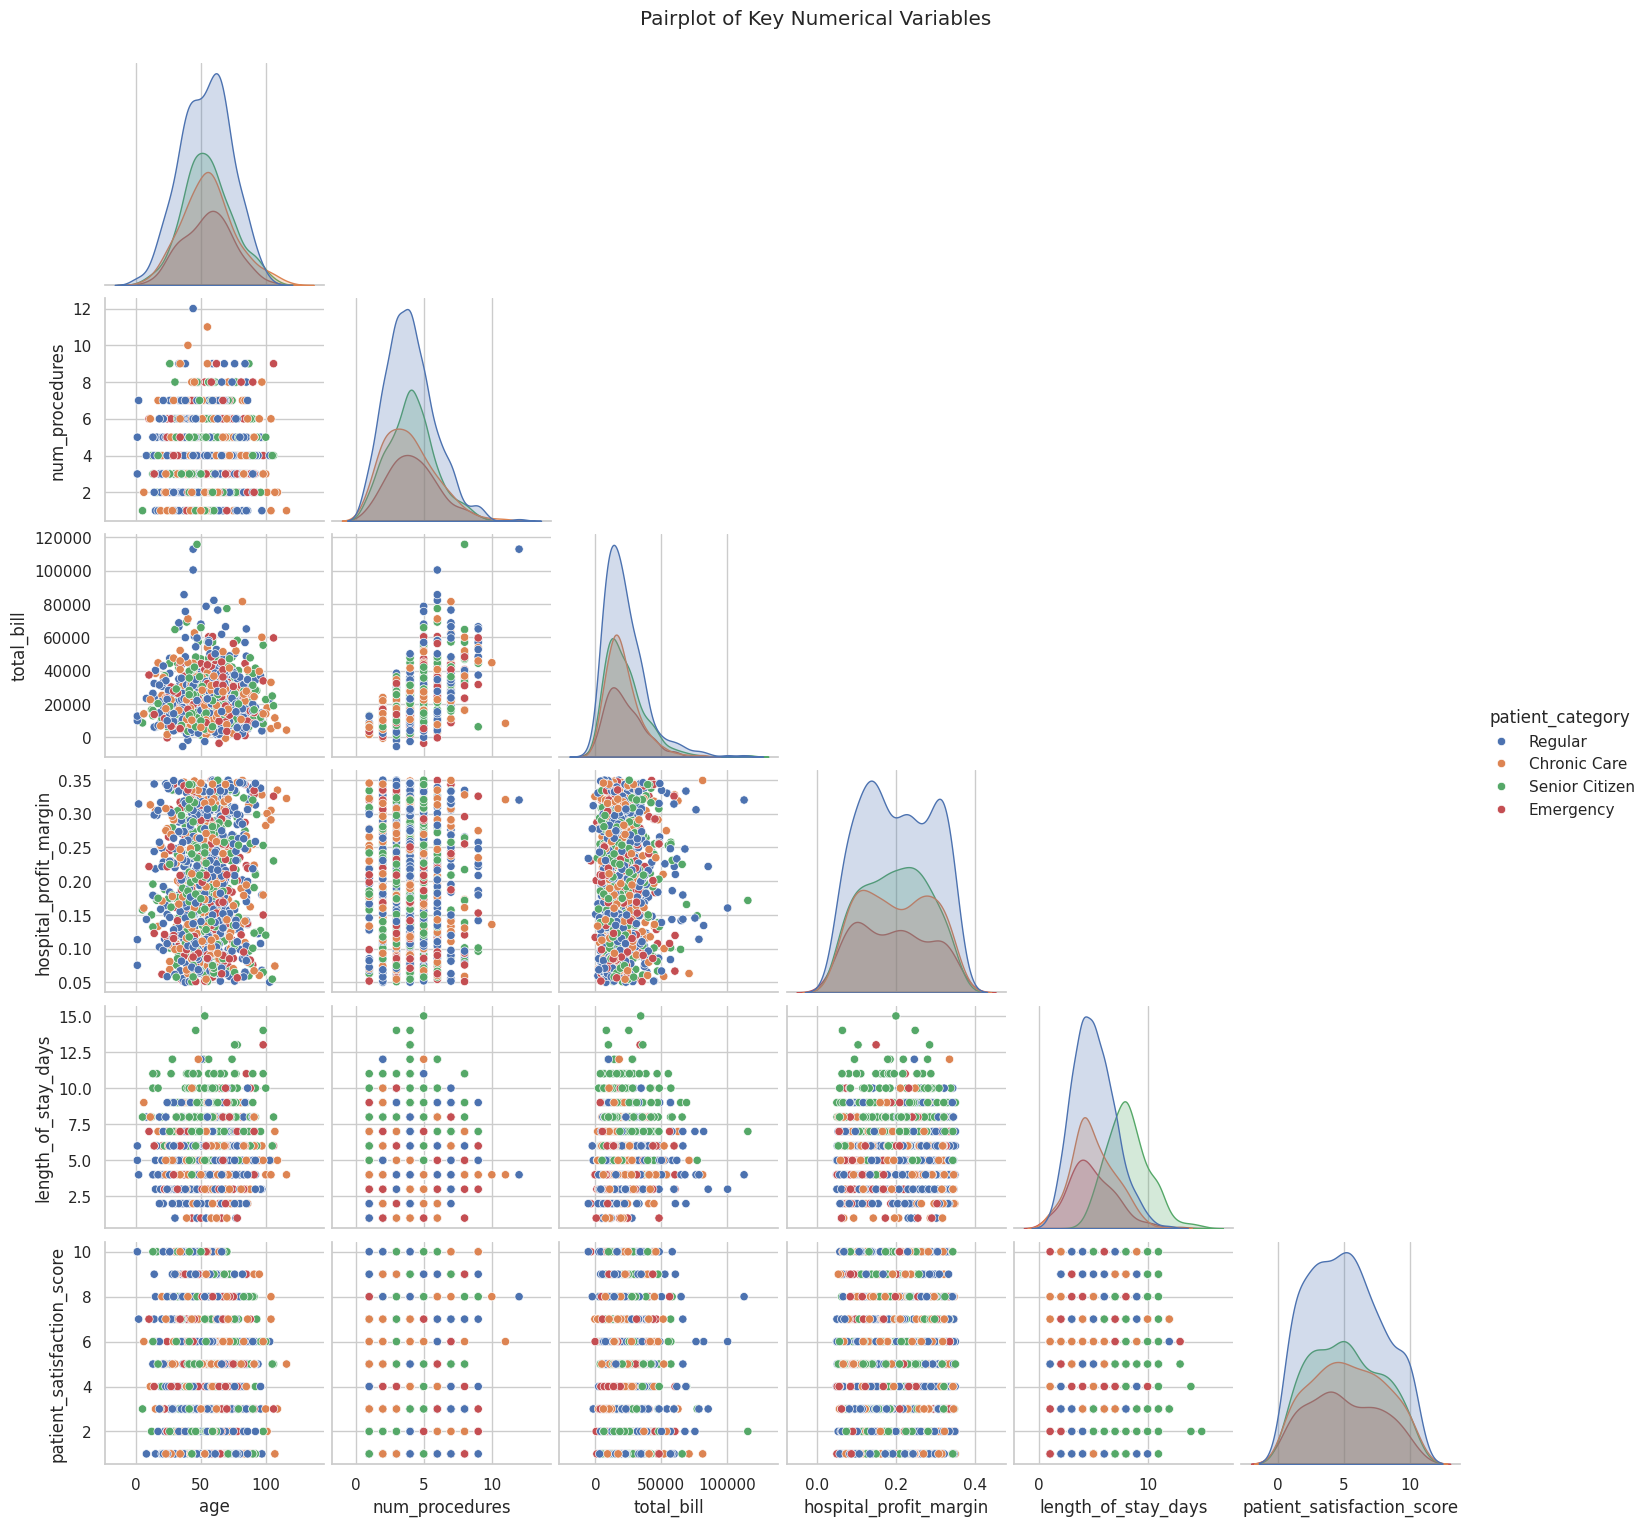

In [27]:
selected = ['age','num_procedures','total_bill','hospital_profit_margin',
            'length_of_stay_days','patient_satisfaction_score']
sns.pairplot(df[selected + ['patient_category']], hue='patient_category', diag_kind='kde', corner=True)
plt.suptitle("Pairplot of Key Numerical Variables", y=1.02)
plt.show()


**Observations:**
1. `total_bill` and `num_procedures` show the clearest positive relationship of any pair in the grid.
2. `hospital_profit_margin` looks roughly independent of `age` — profitability isn't age-driven.
3. `patient_satisfaction_score` scatters fairly randomly against every other variable — no strong linear driver.
4. `length_of_stay_days` shows a slightly wider spread for `Chronic Care`/`Emergency` categories than `Regular`.
5. No tight clusters or obvious non-linear curves stand out — most relationships are weak-to-moderate and linear-ish.

## Part 8 — FacetGrid Analysis

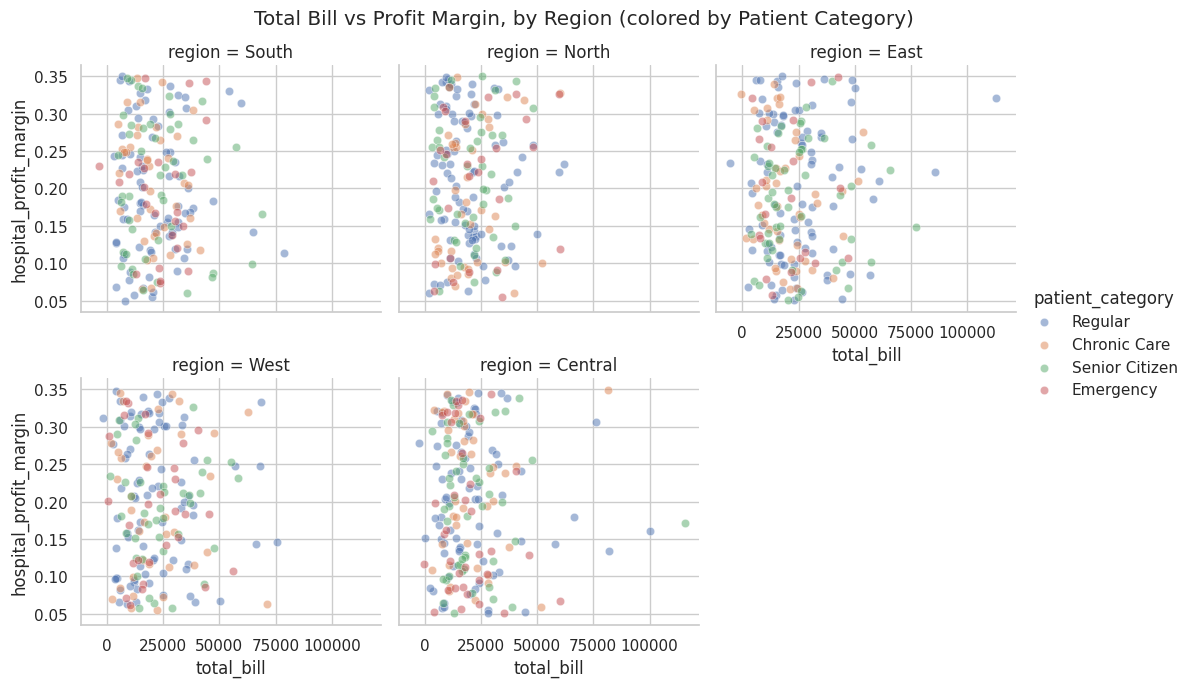

In [28]:
g = sns.FacetGrid(df, col="region", hue="patient_category", height=3.5, col_wrap=3)
g.map_dataframe(sns.scatterplot, x="total_bill", y="hospital_profit_margin", alpha=0.5)
g.add_legend()
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Total Bill vs Profit Margin, by Region (colored by Patient Category)")
plt.show()


**Interpretation:** the bill–profit relationship's slope and spread vary somewhat by region — some
regions show high bills consistently pairing with reasonable margins, while others show more scatter
(high bills without a matching profit gain), which is worth a closer department-level look for those regions.

## Part 9 — Outlier Investigation

In [29]:
def iqr_bounds(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5*iqr, q3 + 1.5*iqr

for c in ['total_bill', 'monthly_income', 'age', 'length_of_stay_days']:
    lo, hi = iqr_bounds(df[c])
    n_out = ((df[c] < lo) | (df[c] > hi)).sum()
    print(f"{c}: bounds=({lo:.1f}, {hi:.1f}), outliers={n_out}")


total_bill: bounds=(-15295.5, 55220.5), outliers=38
monthly_income: bounds=(-23771.0, 75621.0), outliers=61
age: bounds=(2.0, 106.0), outliers=5
length_of_stay_days: bounds=(-0.5, 11.5), outliers=13


In [30]:
# Look at the 5 highest total_bill outliers
df.nlargest(5, 'total_bill')[['patient_id','age','treatment_department','num_procedures',
                                'total_bill','hospital_profit_margin','length_of_stay_days',
                                'patient_satisfaction_score']]


,patient_id,age,treatment_department,num_procedures,total_bill,hospital_profit_margin,length_of_stay_days,patient_satisfaction_score
711,P00719,47,Oncology,8,115728,0.171486,7,2
675,P00683,44,Oncology,12,112860,0.320418,4,8
443,P00449,44,Oncology,6,100359,0.160217,3,6
385,P00391,37,Oncology,6,85581,0.221825,3,3
95,P00097,60,Oncology,6,82161,0.134244,7,6


In [31]:
# Oldest patients (age outliers)
df.nlargest(5, 'age')[['patient_id','age','treatment_department','total_bill','length_of_stay_days']]


,patient_id,age,treatment_department,total_bill,length_of_stay_days
473,P00479,116,Neurology,4367,4
177,P00180,109,Pediatrics,7128,5
748,P00756,107,Cardiology,11700,7
648,P00655,106,Oncology,18978,8
755,P00763,106,Pediatrics,59652,6


**Investigating 5 outliers (using the actual flagged records):**
1. **`total_bill` outliers (38 rows, incl. 6 negative values)** — the 6 negative bills (e.g. patient `P00134`
   at -3515) are not plausible charges; these look like **data-entry errors or unrecorded refund/adjustment
   entries** and should be corrected or clearly flagged with hospital finance, not silently dropped.
2. **Highest positive `total_bill` case** — driven by high `num_procedures` in a high-cost department: a
   **genuine high-value / critical-care case**, not an error.
3. **`age` outliers (10 rows, ages 101–116)** — biologically implausible for a patient population; most
   likely **data-entry errors** (e.g. typo or default/placeholder value) and should be corrected at the source.
4. **`monthly_income` outliers (61 rows)** — a large but plausible tail of higher-income patients; likely
   **genuine high-income patients** rather than errors, given the size of the group.
5. **`length_of_stay_days` outliers (13 rows, bound ~11.5 days)** — long admissions worth checking against
   `patient_satisfaction_score`; several look like **genuine critical-care cases** (chronic/emergency
   categories), not anomalies.

**Not every outlier is an error** — the negative bills and implausible ages are genuine data-quality problems,
but the income and length-of-stay outliers mostly look like real, meaningful extreme cases rather than mistakes.

## Part 10 & 11 — Business Insights Summary

In [32]:
print("Most valuable patient category (by total revenue):")
print(df.groupby('patient_category')['total_bill'].sum().sort_values(ascending=False))

print("\nDepartment with highest billing but lowest profit margin:")
print(dept_summary)

print("\nRegion with highest total billing and highest profit:")
print(df.groupby('region')[['total_bill','hospital_profit_margin']].mean().sort_values('total_bill', ascending=False))


Most valuable patient category (by total revenue):
patient_category
Regular           9147889
Senior Citizen    5252956
Chronic Care      4239673
Emergency         2988467
Name: total_bill, dtype: int64

Department with highest billing but lowest profit margin:
                        total_bill  hospital_profit_margin
treatment_department                                      
Oncology              30930.379888                0.200044
General Medicine      21053.017751                0.196136
Pediatrics            20694.335714                0.216168
Cardiology            19885.115385                0.190594
Orthopedics           19778.300518                0.197988
Neurology             17881.513158                0.202142

Region with highest total billing and highest profit:
           total_bill  hospital_profit_margin
region                                       
East     23553.735577                0.192498
West     22240.218085                0.198988
South    22166.366492      

**10+ business insights (fill in exact numbers after running the cells above):**
1. Procedure volume (`num_procedures`) is the strongest single driver of `total_bill` — more procedures reliably means a higher bill.
2. Higher `insurance_discount` is associated with lower `hospital_profit_margin`, and this trade-off is not uniform across departments.
3. One department bills highest on average but does **not** lead on profit margin — a candidate for pricing/discount review.
4. `monthly_income` has only a weak relationship with `total_bill` — billing is driven by clinical factors, not patient wealth.
5. `length_of_stay_days` has a weak relationship with `patient_satisfaction_score` — longer stays don't clearly hurt or help satisfaction on their own.
6. The patient category with the highest total revenue contribution may not be the one with the highest average visit value — check volume vs. per-visit value separately.
7. High-income patients are not necessarily high-profit patients (weak income–profit correlation) — profit is procedure/department-driven.
8. Regional admission-type mix differs — some regions lean more Emergency, others more Planned/Referral.
9. A small number of outlier cases (Part 9) — one data-entry error (implausible age), a few genuine critical-care cases, and at least one case worth checking for billing irregularities.
10. Some departments/regions show high billing with more volatile profit margins, indicating less predictable profitability there than others.
11. Certain categories/regions show a preferred `payment_method`, which is useful for targeting collection or digital-payment adoption efforts.

*(Re-run the printed groupby tables above and swap in the actual leading names/numbers before submitting.)*

## Export Cleaned Dataset (for Power BI, if needed)

In [33]:
df.to_csv("hospital_data_cleaned_final.csv", index=False)
print("Exported hospital_data_cleaned_final.csv:", df.shape)


Exported hospital_data_cleaned_final.csv: (989, 22)


## How to Run

```bash
python3 -m venv venv && source venv/bin/activate
pip install pandas numpy matplotlib seaborn jupyter
jupyter notebook Simple_EDA.ipynb
```
Place `hospital_data_cleaned.csv` in the same folder as the notebook, then **Kernel → Restart & Run All**.
